# Milestone 2

**SAM pipeline for replica dataset**

That covers:
1. The initialization of the roots for the replica dataset, the SAM model checkpoints and the project
2. Determining the model type and checkpoint; Initializing the model and mask generator

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


1. Initialization of the roots for the replica dataset, the SAM model checkpoints and the project

In [2]:
#imports
from pathlib import Path
import os
import urllib.request
import torch
import cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

In [3]:
# if the code is being run on the cluster, PROJECT_ROOT, REPLICA_ROOT, and CHECKPOINT_DIR needs to be adjusted, like in the following:
"""
export PROJECT_ROOT=/scratch/<user>/ml3d_project
export REPLICA_ROOT=/scratch/<user>/datasets/replica
export CHECKPOINT_DIR=/scratch/<user>/ml3d_project/checkpoints
"""

PROJECT_ROOT = Path(os.environ.get(
    "PROJECT_ROOT",
    "/content/drive/MyDrive/01_uni/02_master/ML3D/project"
))

REPLICA_ROOT = Path(os.environ.get(
    "REPLICA_ROOT",
    PROJECT_ROOT / "replica"
))

CHECKPOINT_DIR = Path(os.environ.get(
    "CHECKPOINT_DIR",
    PROJECT_ROOT / "checkpoints"
))

CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("REPLICA_ROOT:", REPLICA_ROOT)
print("CHECKPOINT_DIR:", CHECKPOINT_DIR)


PROJECT_ROOT: /content/drive/MyDrive/01_uni/02_master/ML3D/project
REPLICA_ROOT: /content/drive/MyDrive/01_uni/02_master/ML3D/project/replica
CHECKPOINT_DIR: /content/drive/MyDrive/01_uni/02_master/ML3D/project/checkpoints


In [7]:
import sys
import subprocess

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from sam_replica_pipeline import replica_dataset_exists

if replica_dataset_exists(REPLICA_ROOT):
    print("Replica dataset already exists:", REPLICA_ROOT)
else:
    print("Replica dataset not found. Downloading...")

    !pip -q install gdown

    REPLICA_ZIP_ID = "1ieM5aFk5JPWhM9W6lsCMriLI_1mLPOBJ"
    REPLICA_ZIP_PATH = PROJECT_ROOT / "replica.zip"

    if not REPLICA_ZIP_PATH.exists():
        !gdown {REPLICA_ZIP_ID} -O "{REPLICA_ZIP_PATH}"
    else:
        print("replica.zip already exists:", REPLICA_ZIP_PATH)

    subprocess.run(
        ["unzip", "-q", str(REPLICA_ZIP_PATH), "-d", str(PROJECT_ROOT)],
        check=True
    )

    print("Download and unzip finished.")

assert replica_dataset_exists(REPLICA_ROOT), f"Replica dataset not found at {REPLICA_ROOT}"

Replica dataset not found. Downloading...
replica.zip already exists: /content/drive/MyDrive/01_uni/02_master/ML3D/project/replica.zip
Download and unzip finished.


In [8]:
#installing all required Python packages for the SAM model itself
!pip -q install git+https://github.com/facebookresearch/segment-anything.git
!pip -q install opencv-python pillow tqdm matplotlib

  Preparing metadata (setup.py) ... done


2. Determine the model type and the checkpoint for the SAM Model and then initialize the model and mask generator

In [9]:
SAM_MODEL_TYPE = "vit_h"
SAM_CHECKPOINT = f"{CHECKPOINT_DIR}/sam_vit_h_4b8939.pth"

url = "https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth"

if not os.path.exists(SAM_CHECKPOINT):
    urllib.request.urlretrieve(url, SAM_CHECKPOINT)

device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [10]:
from segment_anything import SamAutomaticMaskGenerator, sam_model_registry

sam = sam_model_registry[SAM_MODEL_TYPE](checkpoint=SAM_CHECKPOINT)
sam.to(device = device)

mask_generator = SamAutomaticMaskGenerator(
    model = sam,
    #minimum mask quality
    pred_iou_thresh=0.0,
    stability_score_thresh=0.0,
    #parameter for the size of masks
    min_mask_region_area=0
)



3. Check the functionality of the SAM model by testing it on one image and plotting its instance masks

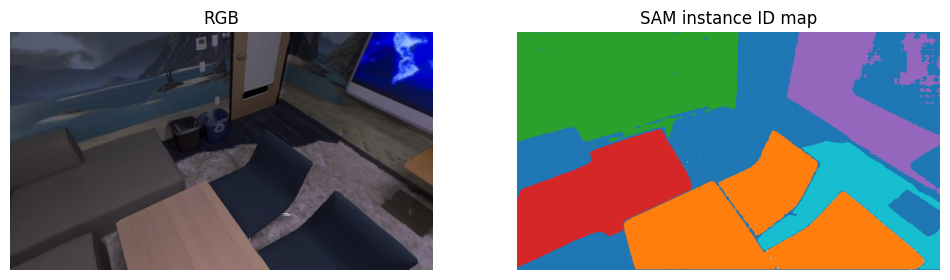

In [13]:
test_image_path = f"{REPLICA_ROOT}/office0/color/0.jpg"

image_bgr = cv2.imread(test_image_path)
assert image_bgr is not None, f"image not found: {test_image_path}"

image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

masks = mask_generator.generate(image_rgb)

MIN_MASK_AREA = 15000
masks = [
    m for m in masks if m["area"] >= MIN_MASK_AREA
]

#sanity check to check number of masks and information per mask
len(masks), masks[0].keys() if len(masks) > 0 else None

height, width = image_rgb.shape[:2]
instance_map = np.zeros((height, width), dtype=np.uint16)

#sort masks descending regarding its surface
masks_filtered = [m for m in masks if m["area"] >= MIN_MASK_AREA and m["stability_score"] > 0.5]
masks_sorted = sorted(masks_filtered, key=lambda x: x["area"], reverse=True)

instance_id = 1

for mask_data in masks_sorted:
    segmentation = mask_data["segmentation"].astype(bool)

    new_pixels = segmentation & (instance_map == 0)

    #add only masks to the instance map, if they span over new pixel
    if new_pixels.sum() == 0:
        continue

    instance_map[new_pixels] = instance_id
    instance_id += 1

# Plot the image and the respective instance map
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(image_rgb)
plt.title("RGB")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(instance_map, cmap="tab20")
plt.title("SAM instance ID map")
plt.axis("off")

plt.show()

5.

In [14]:
from sam_replica_pipeline import SamReplicaMaskPipeline
pipeline = SamReplicaMaskPipeline(
    replica_root=REPLICA_ROOT,
    mask_generator=mask_generator,
    min_area=15000,
    min_stability_score=0.5,
    save_metadata=True
)

In [15]:
"""
scenes = sorted([
    d for d in os.listdir(REPLICA_ROOT)
    if os.path.isdir(os.path.join(REPLICA_ROOT, d))
    and d != "ground_truth"
    and os.path.isdir(os.path.join(REPLICA_ROOT, d, "color"))
])

for scene in scenes:
  pipeline.process_scene(scene)
"""

pipeline.process_scene("office0")

office0:  76%|███████▌  | 151/200 [21:58<07:08,  8.73s/it]


KeyboardInterrupt: 